In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv('bmw_global_sales_dataset.csv')

In [71]:
df.shape
# conclusion 100 rows 14 columns

(1000, 14)

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   str    
 3   model                  1000 non-null   str    
 4   segment                1000 non-null   str    
 5   engine_type            1000 non-null   str    
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), str(4)
memory usage: 109.5 KB


In [73]:
df.isnull().sum()

year                     0
month                    0
country                  0
model                    0
segment                  0
engine_type              0
price_usd                0
marketing_spend_usd      0
dealership_count         0
fuel_price_usd           0
gdp_growth_percent       0
interest_rate_percent    0
competition_index        0
units_sold               0
dtype: int64

In [74]:
df.nunique()
# fuel_price_usd  gdp_growth_percent interest_rate_percent  are sames

year                      10
month                     12
country                   10
model                     10
segment                    3
engine_type                4
price_usd                994
marketing_spend_usd      996
dealership_count         355
fuel_price_usd             1
gdp_growth_percent         1
interest_rate_percent      1
competition_index         10
units_sold               621
dtype: int64

In [75]:
df.drop(columns=['fuel_price_usd', 'interest_rate_percent', 'gdp_growth_percent'], inplace=True)

In [76]:
df.describe().astype('int64')

,year,month,price_usd,marketing_spend_usd,dealership_count,competition_index,units_sold
count,1000,1000,1000,1000,1000,1000,1000
mean,2019,6,76535,279492,200,5,633
std,2,3,25360,127010,113,2,263
min,2015,1,35060,50363,10,1,15
25%,2017,3,54578,173552,101,3,432
50%,2019,7,75726,278733,197,6,630
75%,2022,10,98730,390110,297,8,842
max,2024,12,119817,498927,399,10,1242


In [77]:
df.value_counts()

year  month  country    model     segment   engine_type  price_usd  marketing_spend_usd  dealership_count  competition_index  units_sold
2021  1      Australia  X1        SUV       Petrol       82234      315372               96                8                  324           1
2018  8      Australia  i4        Sedan     Electric     82291      447798               234               7                  556           1
2022  12     USA        5 Series  Electric  Hybrid       40594      259755               25                7                  152           1
2019  11     Australia  i7        SUV       Electric     42371      323541               319               5                  730           1
2021  12     Brazil     X5        SUV       Diesel       82315      482015               367               2                  1156          1
                                                                                                                                           ..
2024  10   

In [78]:
df['segment'].unique()

<StringArray>
['SUV', 'Sedan', 'Electric']
Length: 3, dtype: str

In [79]:
df['model'].unique()

<StringArray>
['X1', 'i4', '5 Series', 'i7', 'X5', 'X7', '3 Series', '7 Series', 'X3', 'iX']
Length: 10, dtype: str

In [80]:
df['engine_type'].unique()

<StringArray>
['Petrol', 'Electric', 'Hybrid', 'Diesel']
Length: 4, dtype: str

In [81]:
df['country'].unique()

<StringArray>
['Australia',       'USA',    'Brazil',     'China',     'India',        'UK',
    'Canada',   'Germany',    'France',     'Japan']
Length: 10, dtype: str

In [82]:
df['segment'].value_counts()

segment
Electric    341
SUV         331
Sedan       328
Name: count, dtype: int64

<Axes: xlabel='units_sold', ylabel='Count'>

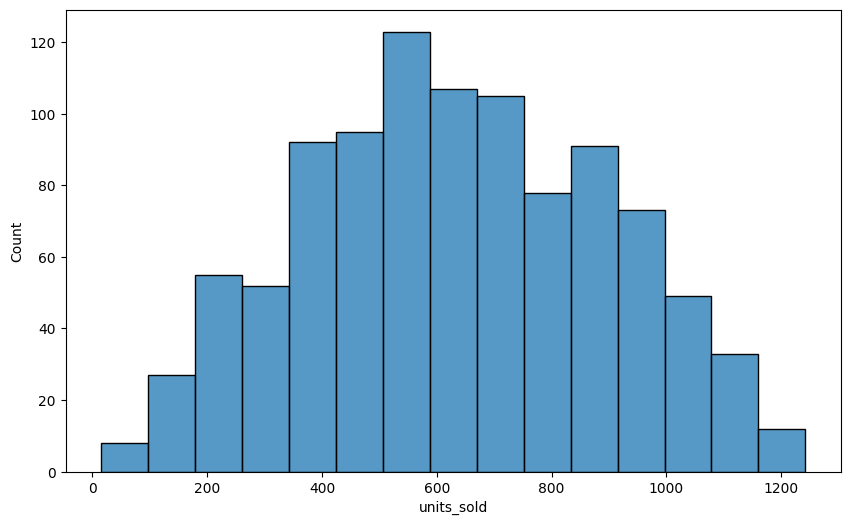

In [83]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='units_sold')

In [84]:
corr = df.corr(numeric_only=True)

<Axes: >

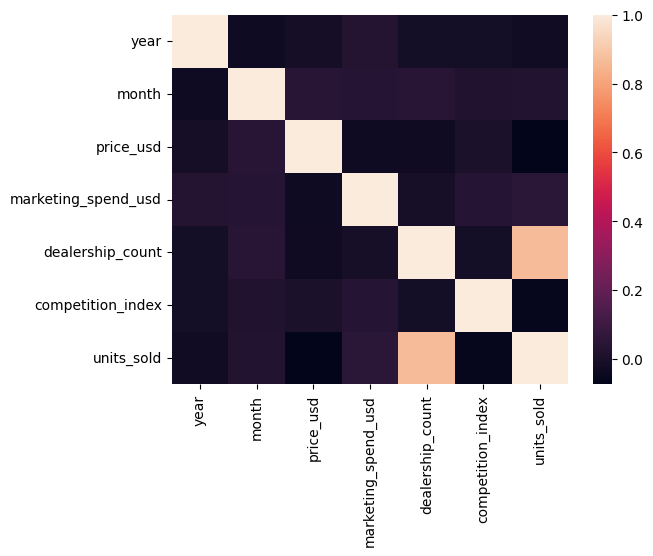

In [85]:
sns.heatmap(data=corr)

In [86]:
help(sns.heatmap)

Help on function heatmap in module seaborn.matrix:

heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)
    Plot rectangular data as a color-encoded matrix.

    This is an Axes-level function and will draw the heatmap into the
    currently-active Axes if none is provided to the ``ax`` argument.  Part of
    this Axes space will be taken and used to plot a colormap, unless ``cbar``
    is False or a separate Axes is provided to ``cbar_ax``.

    Parameters
    ----------
    data : rectangular dataset
        2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
        is provided, the index/column information will be used to label the
        columns and rows.
    vmin, vmax : floats, optional
        Values to anchor the colormap, otherwise they are

In [87]:
help(sns.barplot)

Help on function barplot in module seaborn.categorical:

barplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, hue_norm=None, width=0.8, dodge='auto', gap=0, log_scale=None, native_scale=False, formatter=None, legend='auto', capsize=0, err_kws=None, ci=<deprecated>, errcolor=<deprecated>, errwidth=<deprecated>, ax=None, **kwargs)
    Show point estimates and errors as rectangular bars.

    A bar plot represents an aggregate or statistical estimate for a numeric
    variable with the height of each rectangle and indicates the uncertainty
    around that estimate using an error bar. Bar plots include 0 in the
    axis range, and they are a good choice when 0 is a meaningful value
    for the variable to take.

    See the :ref:`tutorial <categorical_tutorial>` for more information.

    .. note::
        By defa

In [88]:
df

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,2,1156
...,...,...,...,...,...,...,...,...,...,...,...
995,2024,10,UK,i4,Sedan,Electric,64813,126425,177,1,570
996,2024,2,India,3 Series,Sedan,Petrol,119431,473502,56,7,433
997,2022,2,Brazil,5 Series,SUV,Electric,100679,65994,212,1,614
998,2016,1,Brazil,i7,Sedan,Hybrid,45681,161915,223,9,511


<Axes: xlabel='country', ylabel='count'>

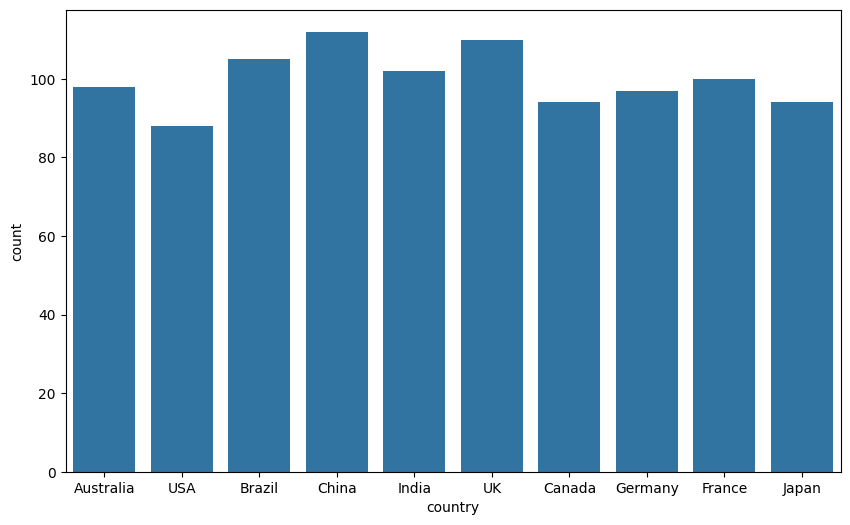

In [89]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='country')

<Axes: >

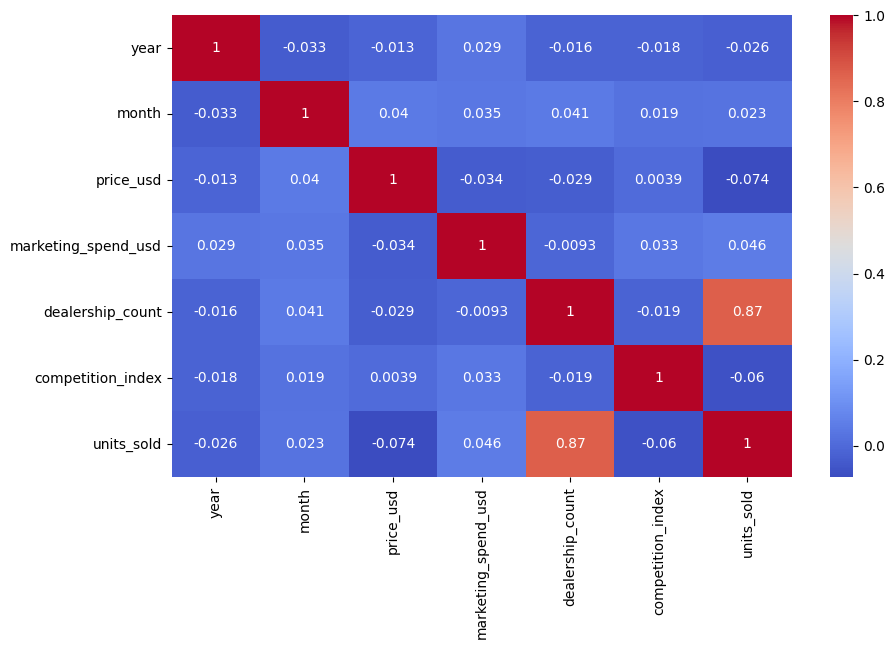

In [90]:
plt.figure(figsize=(10,6))
sns.heatmap(data=df.corr(numeric_only=True), cmap='coolwarm', annot=True)


<Axes: xlabel='price_usd', ylabel='Count'>

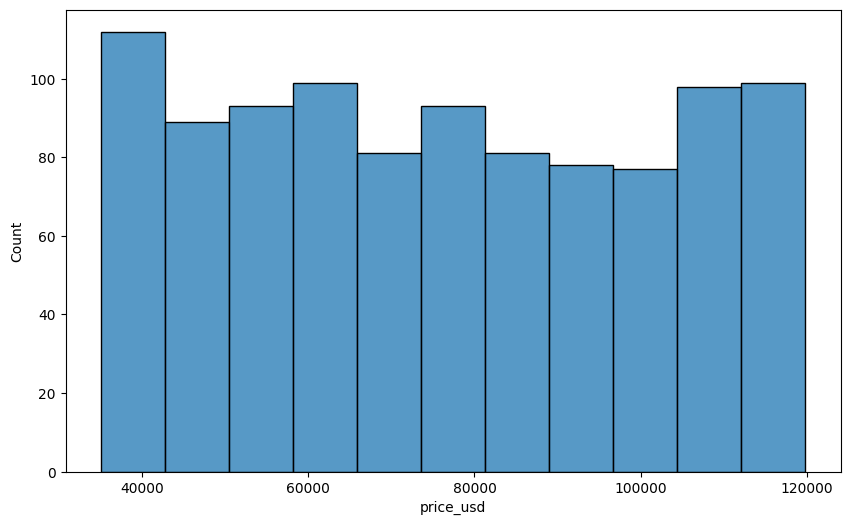

In [91]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='price_usd')

<Axes: xlabel='marketing_spend_usd', ylabel='Count'>

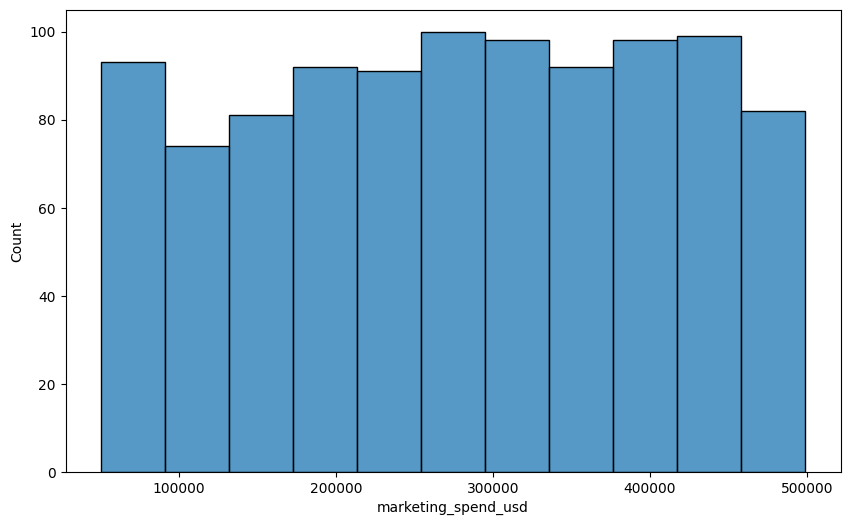

In [92]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='marketing_spend_usd')

<Axes: xlabel='dealership_count', ylabel='Count'>

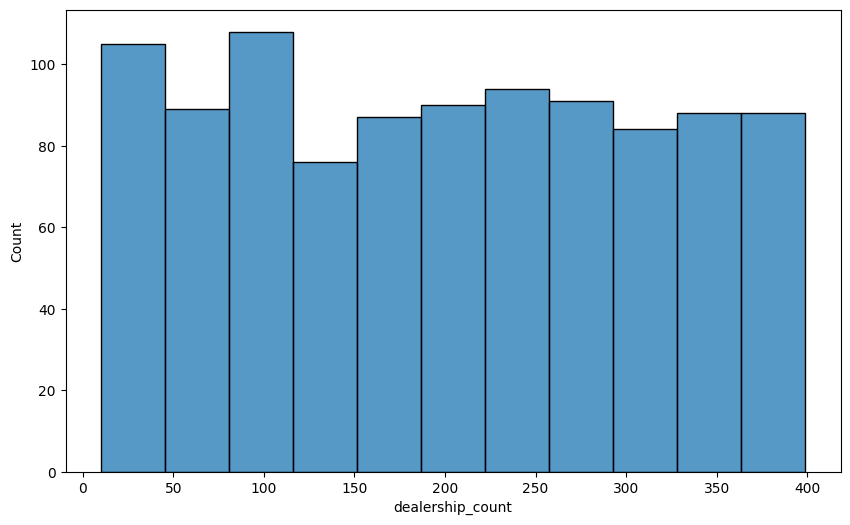

In [93]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='dealership_count')

<Axes: xlabel='dealership_count', ylabel='units_sold'>

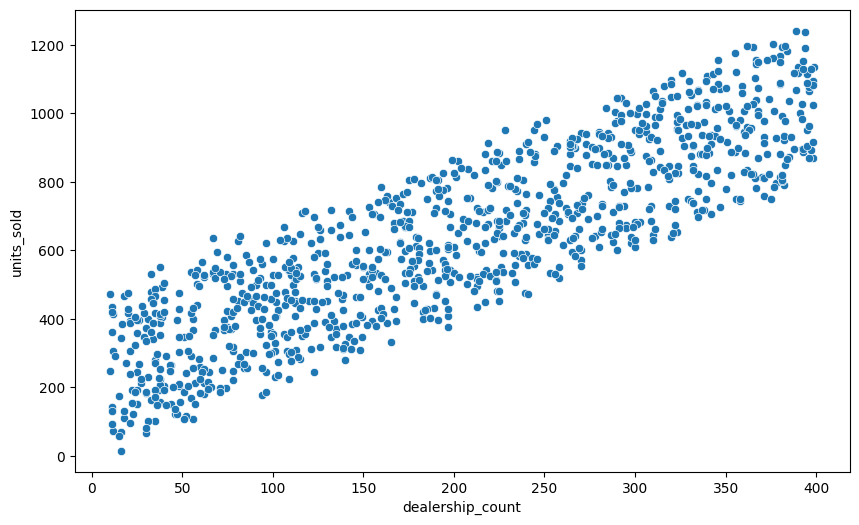

In [94]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='dealership_count', y='units_sold')

In [95]:
df

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,2,1156
...,...,...,...,...,...,...,...,...,...,...,...
995,2024,10,UK,i4,Sedan,Electric,64813,126425,177,1,570
996,2024,2,India,3 Series,Sedan,Petrol,119431,473502,56,7,433
997,2022,2,Brazil,5 Series,SUV,Electric,100679,65994,212,1,614
998,2016,1,Brazil,i7,Sedan,Hybrid,45681,161915,223,9,511


In [96]:
df.loc[df.duplicated()]

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,competition_index,units_sold


In [97]:
df['country'].value_counts()

country
China        112
UK           110
Brazil       105
India        102
France       100
Australia     98
Germany       97
Canada        94
Japan         94
USA           88
Name: count, dtype: int64

In [98]:
df['model'].value_counts()

model
3 Series    115
i4          107
7 Series    107
X3          105
i7          102
X5          102
X1           99
5 Series     92
X7           90
iX           81
Name: count, dtype: int64

In [99]:
df['engine_type'].value_counts()

engine_type
Electric    266
Hybrid      252
Diesel      251
Petrol      231
Name: count, dtype: int64

In [100]:
# china uk buys most bmws
# 3 series and i4 sells most
# electric sells most

In [101]:
x_table = df.drop('units_sold', axis=1)

In [102]:
x_table

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,competition_index
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,8
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,7
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,7
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,5
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,2
...,...,...,...,...,...,...,...,...,...,...
995,2024,10,UK,i4,Sedan,Electric,64813,126425,177,1
996,2024,2,India,3 Series,Sedan,Petrol,119431,473502,56,7
997,2022,2,Brazil,5 Series,SUV,Electric,100679,65994,212,1
998,2016,1,Brazil,i7,Sedan,Hybrid,45681,161915,223,9


In [103]:
y_table = df['units_sold']

In [104]:
y_table

0       324
1       556
2       152
3       730
4      1156
       ... 
995     570
996     433
997     614
998     511
999     891
Name: units_sold, Length: 1000, dtype: int64

In [105]:
numeric = x_table[['year', 'month', 'price_usd',	'marketing_spend_usd', 'dealership_count', 'competition_index']]

In [106]:
categorical = x_table[['model', 'segment', 'engine_type', 'country']]

In [107]:
categorical

,model,segment,engine_type,country
0,X1,SUV,Petrol,Australia
1,i4,Sedan,Electric,Australia
2,5 Series,Electric,Hybrid,USA
3,i7,SUV,Electric,Australia
4,X5,SUV,Diesel,Brazil
...,...,...,...,...
995,i4,Sedan,Electric,UK
996,3 Series,Sedan,Petrol,India
997,5 Series,SUV,Electric,Brazil
998,i7,Sedan,Hybrid,Brazil


In [108]:
numerical1 = x_table.select_dtypes(include=['int64'])

In [109]:
categorical1 = x_table.select_dtypes(include=['string'])

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, X_test, Y_train, Y_test = train_test_split(x_table, y_table, test_size=0.2, random_state=12, shuffle=True)

In [112]:
X_train.isnull().sum()

year                   0
month                  0
country                0
model                  0
segment                0
engine_type            0
price_usd              0
marketing_spend_usd    0
dealership_count       0
competition_index      0
dtype: int64

In [113]:
#no duplicate values so filling not needed

In [114]:
from sklearn.preprocessing import StandardScaler

In [115]:
X_train.dtypes

year                   int64
month                  int64
country                  str
model                    str
segment                  str
engine_type              str
price_usd              int64
marketing_spend_usd    int64
dealership_count       int64
competition_index      int64
dtype: object

In [116]:
X_train.select_dtypes(include=['object'])

C:\Users\ajaya\AppData\Local\Temp\ipykernel_22968\3820157526.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include=['object'])


,country,model,segment,engine_type
56,Germany,i4,Electric,Hybrid
955,France,3 Series,Sedan,Hybrid
231,USA,X5,SUV,Electric
738,UK,X7,Sedan,Electric
740,Japan,X5,Electric,Diesel
...,...,...,...,...
241,Australia,iX,Sedan,Diesel
253,UK,X1,Electric,Diesel
390,Germany,i7,Electric,Electric
667,Canada,X1,Electric,Petrol


In [117]:
X_train.select_dtypes(include=['number'])

,year,month,price_usd,marketing_spend_usd,dealership_count,competition_index
56,2016,11,65573,344499,111,10
955,2015,10,112004,498927,18,7
231,2015,9,81418,416648,33,3
738,2018,8,108779,188266,194,2
740,2018,12,102946,171361,396,10
...,...,...,...,...,...,...
241,2017,9,55470,203857,344,1
253,2022,5,88051,175549,48,8
390,2023,7,119307,208177,67,7
667,2019,3,49626,277369,37,5


In [118]:
categorical_features = X_train.select_dtypes(include=['object'])
numerical_features = X_train.select_dtypes(include=['number'])


C:\Users\ajaya\AppData\Local\Temp\ipykernel_22968\2501914055.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object'])


In [119]:
print("Numeric features:", list(numerical_features))
print("Categorical features:", list(categorical_features))

Numeric features: ['year', 'month', 'price_usd', 'marketing_spend_usd', 'dealership_count', 'competition_index']
Categorical features: ['country', 'model', 'segment', 'engine_type']


In [120]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [121]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [122]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [123]:
from sklearn.compose import ColumnTransformer

In [124]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numerical_features.columns.to_list()),
        ('cat', categorical_pipeline, categorical_features.columns.to_list())
    ]
)

In [125]:
from sklearn.linear_model import LinearRegression

In [126]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

In [127]:
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

In [128]:
print("Numeric features:", numerical_features.columns.tolist())
print("Categorical features:", categorical_features.columns.tolist())

Numeric features: ['year', 'month', 'price_usd', 'marketing_spend_usd', 'dealership_count', 'competition_index']
Categorical features: ['country', 'model', 'segment', 'engine_type']


In [129]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [130]:
r2 = r2_score(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_pred)

In [131]:
print("R2:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

R2: 0.7237837262656257
MSE: 18328.987547835208
RMSE: 135.3845912496515
MAE: 116.77260915444705


In [132]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [133]:
def cv_rmse(model_pipeline, X, y, folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)
    scores = cross_val_score(
        model_pipeline, X, y,
        scoring='neg_root_mean_squared_error',
        cv=kf
    )
    rmse_scores = -scores
    return rmse_scores.mean(), rmse_scores.std()


In [134]:
lin_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

In [136]:
lin_mean, lin_std = cv_rmse(lin_pipe, X_train, Y_train)
ridge_mean, ridge_std= cv_rmse(ridge_pipe, X_train, Y_train)
rf_mean, rf_std = cv_rmse(rf_pipe, X_train, Y_train)

In [137]:
results = {
    'Linear': (lin_mean, lin_std),
    'Ridge': (ridge_mean, ridge_std),
    'RandomForest': (rf_mean, rf_std)
}

best_name = min(results, key=lambda x : results[x][0])
print("Best model by CV RMSE: ", best_name, results[best_name])



Best model by CV RMSE:  Ridge (np.float64(129.0695811967949), np.float64(3.120144252518446))


: 

: 

: 

In [139]:
print(f"Linear RMSE CV: {lin_mean:.2f} +- {lin_std:.2f}")
print(f"Ridge  RMSE CV: {ridge_mean:.2f} +- {ridge_std:.2f}")
print(f"RF     RMSE CV: {rf_mean:.2f} +- {rf_std:.2f}")
print("Best model:", best_name)

Linear RMSE CV: 129.13 +- 3.14
Ridge  RMSE CV: 129.07 +- 3.12
RF     RMSE CV: 135.19 +- 2.54
Best model: Ridge


In [141]:
from sklearn.model_selection import GridSearchCV

In [142]:
ridge_tune_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',Ridge())
])

In [143]:
param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1, 3, 10, 30, 100]
}

grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, Y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...r', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [144]:
print("Best alpha", grid.best_params_['regressor__alpha'])
print('Best CV RMSE', -grid.best_score_)


Best alpha 30
Best CV RMSE 128.8399149781549


In [145]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

best_r2 = r2_score(Y_test, y_pred_best)
best_mae = mean_absolute_error(Y_test, y_pred_best)
best_rmse = mean_squared_error(Y_test, y_pred_best)

print("Test R2:", best_r2)
print("Test MAE:", best_mae)
print("Test RMSE:", np.sqrt(best_rmse))

Test R2: 0.7281929092547971
Test MAE: 116.5080011483252
Test RMSE: 134.29968625337958


: 

In [146]:
print('best_alpha =', grid.best_params_['regressor__alpha'])
print('best_cv_rmse =', -grid.best_score_)
print('test_r2 =', best_r2)
print('test_mae =', best_mae)
print('test_rmse =', np.sqrt(best_rmse))

best_alpha = 30
best_cv_rmse = 128.8399149781549
test_r2 = 0.7281929092547971
test_mae = 116.5080011483252
test_rmse = 134.29968625337958


In [147]:
df['country'].astype('category').cat.codes

0      0
1      0
2      9
3      0
4      1
      ..
995    8
996    6
997    1
998    1
999    3
Length: 1000, dtype: int8